In [1]:
!pwd
import os, sys
os.chdir('/home/rdkeller/zebrafish_agent/')
os.environ["MUJOCO_GL"] = "egl"
!pwd

/home/rdkeller/zebrafish_agent/zfa_rl_agent/analysis/brain-model


/home/rdkeller/zebrafish_agent


In [2]:
from collections import defaultdict
from pathlib import Path
from stable_baselines3.common.utils import obs_as_tensor

import torch as th
from zfa_rl_agent.core.agent.PPO.rPPO import PPO
from zfa_rl_agent.core.environments.grating import swimmer_grating_venv
from zfa_rl_agent.core.environments.zebrafish import swimmer_venv



libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card1: Permission denied



In [3]:
MODEL_PATH = ("/home/rdkeller/zebrafish_agent/zfa_rl_agent/analysis/local_models/policies/base_swimmer.zip")

In [4]:
# env = swimmer_grating_venv(
#     parallel=0,
#     use_ray=0,
#     n_envs=1,          # single‑env rollout for clarity
#     seed=123,
#     monitor_dir=None,
#     grating_speed=0.01,
# )

env = swimmer_venv(
    parallel=1,
    use_ray=0,
    n_envs=3,          # single‑env rollout for clarity
    seed=123,
    monitor_dir=None,
    force_magnitude=0.0
)
model = PPO.load(MODEL_PATH, env=env, device="cpu")  # change device if needed
policy = model.policy
policy.eval()
th.set_grad_enabled(False)

2025-04-30 16:19:36,227 - zfa_rl_agent.core.utils.logger - INFO - Vectorizing with SubprocVecEnv
INFO:zfa_rl_agent.core.utils.logger:Vectorizing with SubprocVecEnv
libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card8: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card7: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card6: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card5: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card4: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card3: Permission denied

libEGL warning: egl: failed to create dri2 screen
libEGL warning: failed to open /dev/dri/card2: Permission denied

libEGL warning: egl: fai

345


In [5]:
activations = defaultdict(list)
step_idx = {"i": 0}

def _make_hook(name: str):
    def hook(_, __, out):
        # Store only if we have not yet captured for this layer at this step
        if len(activations[name]) == step_idx["i"]:
            if isinstance(out, (tuple, list)):
                _, (h_n, _c_n) = out
                saved = h_n.squeeze(1).squeeze(0).detach().cpu()  # remove batch dim
                print(saved.shape)
            else:
                saved = out.detach().cpu()
                print(saved.shape)
            activations[name].append(saved)
    return hook

for name, module in policy.named_modules():
    if len(list(module.children())) == 0:  # leaf module
        print(name)
        module.register_forward_hook(_make_hook(name))

features_extractor.extractors.pixels.cnn.0
features_extractor.extractors.pixels.cnn.1
features_extractor.extractors.pixels.cnn.2
features_extractor.extractors.pixels.cnn.3
features_extractor.extractors.pixels.cnn.4
features_extractor.extractors.pixels.cnn.5
features_extractor.extractors.pixels.cnn.6
features_extractor.extractors.pixels.linear.0
features_extractor.extractors.pixels.linear.1
features_extractor.extractors.proprio.mlp.0
features_extractor.extractors.proprio.mlp.1
features_extractor.extractors.proprio.mlp.2
mlp_extractor.policy_net.0
mlp_extractor.policy_net.1
mlp_extractor.policy_net.2
mlp_extractor.policy_net.3
mlp_extractor.value_net.0
mlp_extractor.value_net.1
mlp_extractor.value_net.2
mlp_extractor.value_net.3
action_net
value_net
lstm_actor
lstm_critic


In [6]:
obs = env.reset()
episode_start = th.zeros(env.num_envs, dtype=th.bool)
N_STEPS = 10
obs_arr = []
for _ in range(N_STEPS):
    obs_arr.append(obs['pixels'])
    action, _ = model.predict(obs, deterministic=True)
    obs_tensor = obs_as_tensor(obs, device=model.device)
    with th.no_grad():
        _ = policy.predict_values(
            obs_tensor,
            lstm_states=model._last_lstm_states.vf,
            episode_starts=episode_start,
        )
    obs, _, dones, _ = env.step(action)
    episode_start = th.as_tensor(dones, device=model.device)
            # allow hooks to capture on the next step
        # done with this env step
    step_idx["i"] += 1
stacked = {k: th.stack(v, dim=0) for k, v in activations.items()}

torch.Size([3, 32, 15, 15])
torch.Size([3, 32, 15, 15])
torch.Size([3, 64, 6, 6])
torch.Size([3, 64, 6, 6])
torch.Size([3, 64, 4, 4])
torch.Size([3, 64, 4, 4])
torch.Size([3, 1024])
torch.Size([3, 256])
torch.Size([3, 256])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 256])
torch.Size([3, 128])
torch.Size([3, 128])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 5])
torch.Size([3, 256])
torch.Size([3, 128])
torch.Size([3, 128])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 1])
torch.Size([3, 32, 15, 15])
torch.Size([3, 32, 15, 15])
torch.Size([3, 64, 6, 6])
torch.Size([3, 64, 6, 6])
torch.Size([3, 64, 4, 4])
torch.Size([3, 64, 4, 4])
torch.Size([3, 1024])
torch.Size([3, 256])
torch.Size([3, 256])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 256])
torch.Size([3, 128])
torch.Size([3, 128])
torch.Size([3, 64])
torch.Size([3, 64])
torch.Size([3, 5])
torch.Size([3, 256])
torch.Size([3, 128])
torch.Size([3, 128])
tor

In [7]:
for key in stacked.keys():
    print(f"Shape of {key}: {stacked[key].shape}")


Shape of features_extractor.extractors.pixels.cnn.0: torch.Size([10, 3, 32, 15, 15])
Shape of features_extractor.extractors.pixels.cnn.1: torch.Size([10, 3, 32, 15, 15])
Shape of features_extractor.extractors.pixels.cnn.2: torch.Size([10, 3, 64, 6, 6])
Shape of features_extractor.extractors.pixels.cnn.3: torch.Size([10, 3, 64, 6, 6])
Shape of features_extractor.extractors.pixels.cnn.4: torch.Size([10, 3, 64, 4, 4])
Shape of features_extractor.extractors.pixels.cnn.5: torch.Size([10, 3, 64, 4, 4])
Shape of features_extractor.extractors.pixels.cnn.6: torch.Size([10, 3, 1024])
Shape of features_extractor.extractors.pixels.linear.0: torch.Size([10, 3, 256])
Shape of features_extractor.extractors.pixels.linear.1: torch.Size([10, 3, 256])
Shape of features_extractor.extractors.proprio.mlp.0: torch.Size([10, 3, 64])
Shape of features_extractor.extractors.proprio.mlp.1: torch.Size([10, 3, 64])
Shape of features_extractor.extractors.proprio.mlp.2: torch.Size([10, 3, 64])
Shape of lstm_actor: to

In [8]:
import matplotlib.pyplot as plt
pixels = obs_arr[0].squeeze()  # Extract the pixel data
print(pixels.shape)
plt.imshow(pixels.transpose(1, 2, 0))  # Rearrange dimensions for display

(3, 3, 64, 64)


ValueError: axes don't match array

In [ ]:
for key in stacked.keys():
    print(key)

features_extractor.extractors.pixels.cnn.0
features_extractor.extractors.pixels.cnn.1
features_extractor.extractors.pixels.cnn.2
features_extractor.extractors.pixels.cnn.3
features_extractor.extractors.pixels.cnn.4
features_extractor.extractors.pixels.cnn.5
features_extractor.extractors.pixels.cnn.6
features_extractor.extractors.pixels.linear.0
features_extractor.extractors.pixels.linear.1
features_extractor.extractors.proprio.mlp.0
features_extractor.extractors.proprio.mlp.1
features_extractor.extractors.proprio.mlp.2
lstm_actor
mlp_extractor.policy_net.0
mlp_extractor.policy_net.1
mlp_extractor.policy_net.2
mlp_extractor.policy_net.3
action_net
lstm_critic
mlp_extractor.value_net.0
mlp_extractor.value_net.1
mlp_extractor.value_net.2
mlp_extractor.value_net.3
value_net


In [ ]:
stacked['lstm_actor'].shape

torch.Size([10, 1, 1, 256])

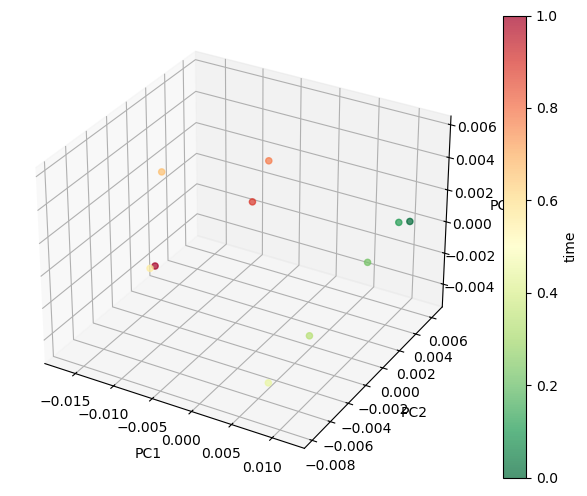

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

data_tensor = stacked['lstm_critic']
data_np = data_tensor.view(data_tensor.shape[0], -1).numpy()
pca = PCA(n_components=3)
pcs = pca.fit_transform(data_np)
times = np.linspace(0, 1, pcs.shape[0])

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(pcs[:, 0], pcs[:, 1], pcs[:, 2], c=times, cmap="RdYlGn_r", alpha=0.7)
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
fig.colorbar(sc, ax=ax, label="time")
plt.show()